# IPC Kenya Food Insecurity Exploratory Data Analysis

This notebook explores the cleaned IPC county-level dataset created from the raw HDX IPC food insecurity data.

Main questions:
1. Which counties experienced the most severe IPC phases?
2. Which counties had the highest share of people in Crisis level or worse?
3. Which counties had the largest number of people affected?
4. How did food insecurity change over time?
5. Which counties repeatedly appeared as high-risk areas?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
PROCESSED_PATH = Path("../02_data/processed/ipc_max_phase_per_county.csv")

df = pd.read_csv(PROCESSED_PATH)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (322, 7)


,date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     322 non-null    str    
 1   analysis_period          322 non-null    str    
 2   county                   322 non-null    str    
 3   max_ipc_phase            322 non-null    int64  
 4   phase_3_plus_population  322 non-null    int64  
 5   total_population         322 non-null    int64  
 6   phase_3_plus_percentage  322 non-null    float64
dtypes: float64(1), int64(3), str(3)
memory usage: 17.7 KB


In [5]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     322 non-null    datetime64[us]
 1   analysis_period          322 non-null    str           
 2   county                   322 non-null    str           
 3   max_ipc_phase            322 non-null    int64         
 4   phase_3_plus_population  322 non-null    int64         
 5   total_population         322 non-null    int64         
 6   phase_3_plus_percentage  322 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 17.7 KB


## Question 1: Which Counties Reached IPC Phase 4 Most Often?

IPC Phase 4 means Emergency level food insecurity. In this step, we count how many times each county reached IPC Phase 4 or above across the available analysis periods.

This helps identify counties that repeatedly experienced severe food insecurity conditions.

In [6]:
phase4_counts = (
    df[df["max_ipc_phase"] >= 4]
    .groupby("county")
    .size()
    .reset_index(name="phase4_or_above_count")
    .sort_values("phase4_or_above_count", ascending=False)
)

phase4_counts

,county,phase4_or_above_count
15,Turkana,13
10,Mandera,13
16,Wajir,12
11,Marsabit,11
2,Garissa,9
13,Samburu,9
3,Isiolo,9
14,Tana River,8
0,Baringo,6
5,Kitui,3


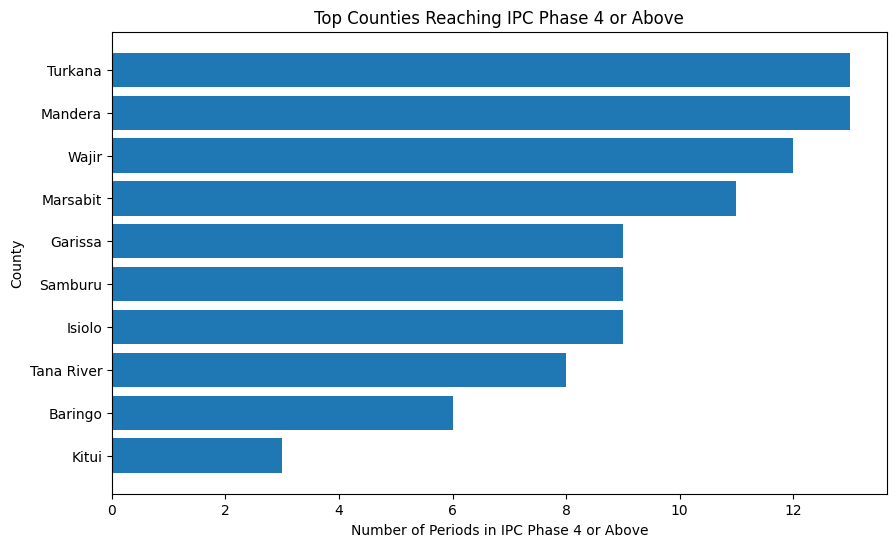

In [7]:
top_phase4 = phase4_counts.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_phase4["county"], top_phase4["phase4_or_above_count"])
plt.xlabel("Number of Periods in IPC Phase 4 or Above")
plt.ylabel("County")
plt.title("Top Counties Reaching IPC Phase 4 or Above")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

Turkana and Mandera recorded the highest number of IPC Phase 4 or above periods, each reaching Emergency-level food insecurity in 13 out of 14 current analysis periods. Wajir and Marsabit also appeared frequently, with 12 and 11 Phase 4+ periods respectively.

This suggests that northern and arid counties such as Turkana, Mandera, Wajir, and Marsabit are repeatedly exposed to severe food insecurity conditions. These counties should be treated as priority areas for early warning monitoring, humanitarian planning, and deeper analysis in the next stages of the project.

However, this result only measures severity frequency. It does not yet show how many people were affected or what share of the county population was in Crisis or worse. The next analysis will compare counties using `phase_3_plus_percentage` and `phase_3_plus_population`.

## Question 2: Which Counties Had the Highest Average Share of People in Crisis or Worse?

IPC Phase 3 or above means Crisis, Emergency, or worse. This section calculates the average share of each county's population that was classified as Phase 3+ across all available current IPC analysis periods.

This helps identify counties where food insecurity affected a large proportion of the population over time.

In [8]:
avg_phase3_percentage = (
    df.groupby("county")["phase_3_plus_percentage"]
    .mean()
    .reset_index(name="avg_phase_3_plus_percentage")
    .sort_values("avg_phase_3_plus_percentage", ascending=False)
)

avg_phase3_percentage

,county,avg_phase_3_plus_percentage
20,Turkana,0.302979
11,Mandera,0.292857
12,Marsabit,0.291979
21,Wajir,0.250000
2,Garissa,0.242857
3,Isiolo,0.232143
18,Tana River,0.232143
16,Samburu,0.221429
0,Baringo,0.164286
7,Kwale,0.114286


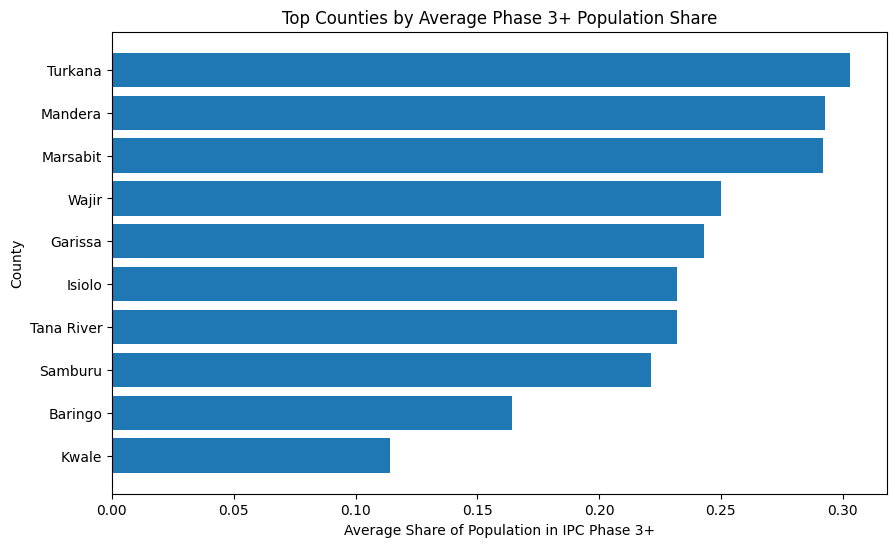

In [9]:
top_avg_phase3 = avg_phase3_percentage.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_avg_phase3["county"], top_avg_phase3["avg_phase_3_plus_percentage"])
plt.xlabel("Average Share of Population in IPC Phase 3+")
plt.ylabel("County")
plt.title("Top Counties by Average Phase 3+ Population Share")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

Turkana had the highest average share of people in IPC Phase 3 or worse, followed by Mandera, Marsabit, Wajir, and Garissa. This means these counties did not only experience severe IPC classifications; a large proportion of their populations were also affected over time.

This confirms that northern and arid counties are consistently among the highest-risk areas in the dataset. Turkana, Mandera, Marsabit, and Wajir appear important under both severity frequency and population-share analysis.

Compared with the previous Phase 4 frequency chart, this analysis gives a broader view of humanitarian impact because it measures the share of people in Crisis level or worse, not just the highest IPC phase reached.

## Question 3: Which County-Periods Had the Largest Number of People in Crisis or Worse?

This section identifies the county and analysis-period combinations with the largest number of people classified in IPC Phase 3 or worse.

This helps measure the absolute humanitarian burden, not just the percentage of the population affected.

In [10]:
top_affected_periods = (
    df.sort_values("phase_3_plus_population", ascending=False)
    .head(15)
    [
        [
            "analysis_period",
            "county",
            "max_ipc_phase",
            "phase_3_plus_population",
            "total_population",
            "phase_3_plus_percentage"
        ]
    ]
)

top_affected_periods

,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage
172,Jan 2023,Mandera,4,527579,959236,0.55
181,Jan 2023,Turkana,4,511387,1022773,0.50
163,Jan 2023,Garissa,4,509867,927031,0.55
310,Feb 2026,Mandera,4,503500,1007000,0.50
182,Jan 2023,Wajir,4,478849,870636,0.55
158,Jul 2022,Turkana,4,463488,926976,0.50
149,Jul 2022,Mandera,4,390356,867457,0.45
20,Jul 2019,Turkana,4,379278,1083653,0.35
140,Jul 2022,Garissa,4,378609,841353,0.45
135,Feb 2022,Turkana,4,370791,926976,0.40


In [11]:
top_affected_periods = top_affected_periods.copy()

top_affected_periods["county_period"] = (
    top_affected_periods["county"] + " (" + top_affected_periods["analysis_period"] + ")"
)

top_affected_periods.head()

,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,county_period
172,Jan 2023,Mandera,4,527579,959236,0.55,Mandera (Jan 2023)
181,Jan 2023,Turkana,4,511387,1022773,0.50,Turkana (Jan 2023)
163,Jan 2023,Garissa,4,509867,927031,0.55,Garissa (Jan 2023)
310,Feb 2026,Mandera,4,503500,1007000,0.50,Mandera (Feb 2026)
182,Jan 2023,Wajir,4,478849,870636,0.55,Wajir (Jan 2023)


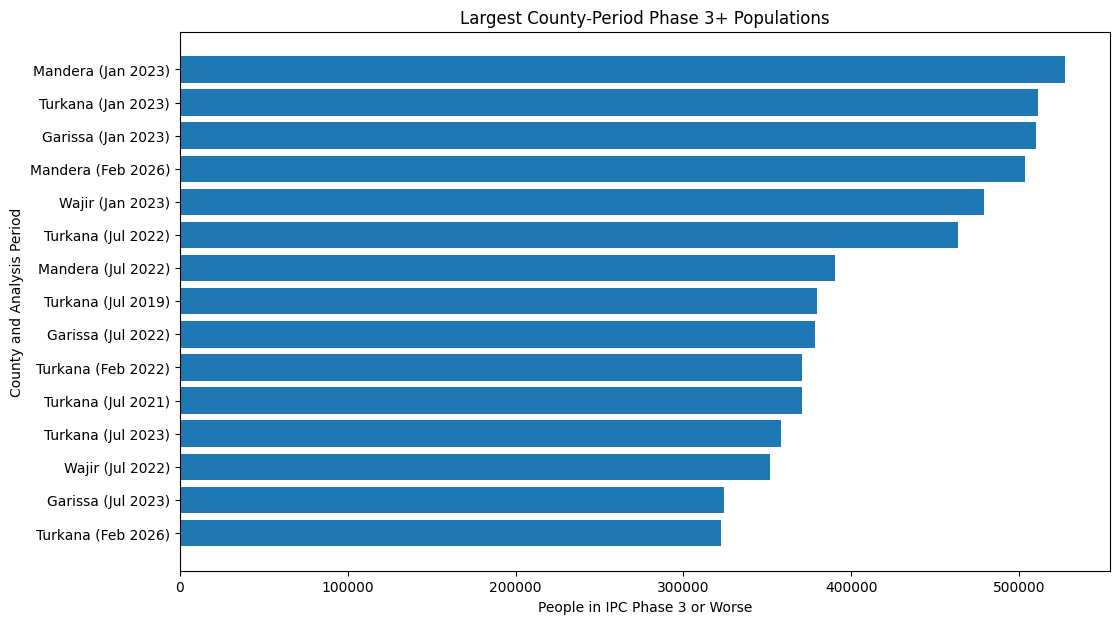

In [12]:
plt.figure(figsize=(12, 7))
plt.barh(
    top_affected_periods["county_period"],
    top_affected_periods["phase_3_plus_population"]
)

plt.xlabel("People in IPC Phase 3 or Worse")
plt.ylabel("County and Analysis Period")
plt.title("Largest County-Period Phase 3+ Populations")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

The largest county-period Phase 3+ populations were concentrated in Mandera, Turkana, Garissa, and Wajir. Mandera in Jan 2023 recorded the highest number of people in IPC Phase 3 or worse, followed closely by Turkana and Garissa in the same period.

This shows that Jan 2023 was one of the most severe periods in the dataset in terms of absolute humanitarian burden. While earlier analysis showed which counties repeatedly reached severe IPC phases, this analysis shows where the largest number of people were affected.

Mandera, Turkana, Garissa, and Wajir should be treated as priority counties because they appear strongly in severity frequency, population-share, and absolute population burden analysis.

## Question 4: How Did Phase 3+ Population Change Over Time?

This section aggregates the number of people in IPC Phase 3 or worse across all target counties for each analysis period.

This helps identify periods where overall food insecurity burden increased or decreased.

In [13]:
phase3_trend = (
    df.groupby(["date", "analysis_period"], as_index=False)["phase_3_plus_population"]
    .sum()
    .sort_values("date")
)

phase3_trend

,date,analysis_period,phase_3_plus_population
0,2019-07-01,Jul 2019,2567437
1,2020-02-01,Feb 2020,1319390
2,2020-08-01,Aug 2020,739101
3,2021-02-01,Feb 2021,1425209
4,2021-07-01,Jul 2021,2147841
5,2022-02-01,Feb 2022,3071640
6,2022-07-01,Jul 2022,3513306
7,2023-01-01,Jan 2023,4389778
8,2023-07-01,Jul 2023,2786550
9,2024-02-01,Feb 2024,1931900


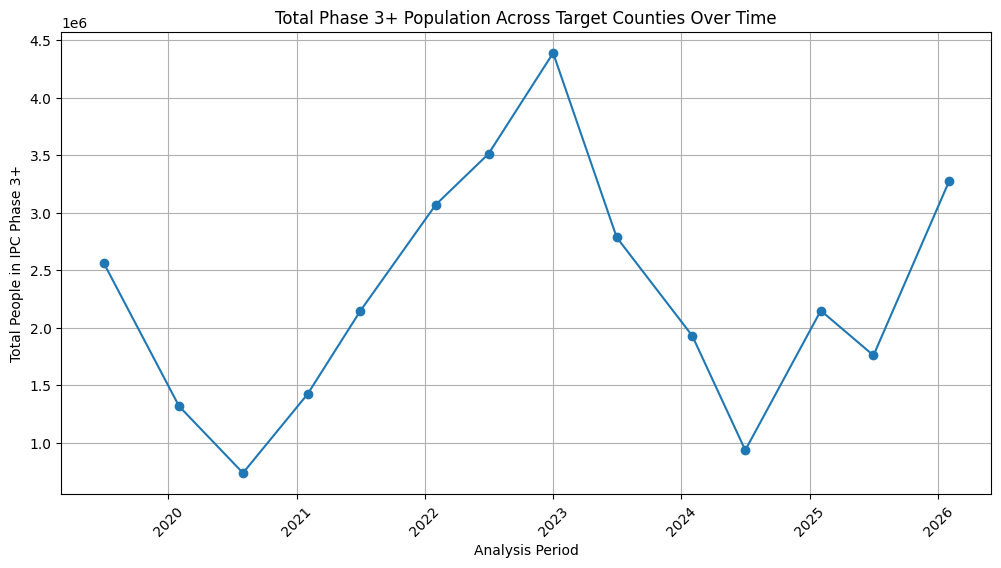

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(
    phase3_trend["date"],
    phase3_trend["phase_3_plus_population"],
    marker="o"
)

plt.xlabel("Analysis Period")
plt.ylabel("Total People in IPC Phase 3+")
plt.title("Total Phase 3+ Population Across Target Counties Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Interpretation

The total number of people in IPC Phase 3 or worse changed significantly over time across the target counties. The overall burden declined after Jul 2019, reached a lower point around 2020, and then increased steadily through 2021 and 2022.

The highest point in the dataset appears around Jan 2023, when the total Phase 3+ population across the target counties reached approximately 4.4 million people. This suggests Jan 2023 was the most severe period in the cleaned dataset in terms of total humanitarian burden.

After Jan 2023, the total Phase 3+ population declined, but the chart shows another increase toward Feb 2026. This indicates that food insecurity pressure may be rising again and should be monitored closely in later forecasting work.

## Question 5: Which Counties Were Repeatedly High-Risk?

This section identifies counties that repeatedly appeared in severe food insecurity conditions across the dataset.

A county is considered high-risk if it frequently reached IPC Phase 3 or worse, especially Phase 4, and had a high average share of its population in Crisis or worse.

In [15]:
phase3_counts = (
    df[df["max_ipc_phase"] >= 3]
    .groupby("county")
    .size()
    .reset_index(name="phase3_or_above_count")
    .sort_values("phase3_or_above_count", ascending=False)
)

phase3_counts

,county,phase3_or_above_count
0,Baringo,14
2,Garissa,14
3,Isiolo,14
5,Kilifi,14
12,Marsabit,14
9,Lamu,14
7,Kwale,14
20,Turkana,14
21,Wajir,14
18,Tana River,14


In [16]:
risk_summary = (
    phase3_counts
    .merge(phase4_counts, on="county", how="left")
    .merge(avg_phase3_percentage, on="county", how="left")
)

risk_summary["phase4_or_above_count"] = risk_summary["phase4_or_above_count"].fillna(0).astype(int)

risk_summary = risk_summary.sort_values(
    ["phase4_or_above_count", "avg_phase_3_plus_percentage", "phase3_or_above_count"],
    ascending=False
)

risk_summary.head(15)

,county,phase3_or_above_count,phase4_or_above_count,avg_phase_3_plus_percentage
7,Turkana,14,13,0.302979
10,Mandera,14,13,0.292857
8,Wajir,14,12,0.250000
4,Marsabit,14,11,0.291979
1,Garissa,14,9,0.242857
2,Isiolo,14,9,0.232143
11,Samburu,14,9,0.221429
9,Tana River,14,8,0.232143
0,Baringo,14,6,0.164286
16,Kitui,11,3,0.110714


In [17]:
high_risk_counties = risk_summary.head(10)

high_risk_counties

,county,phase3_or_above_count,phase4_or_above_count,avg_phase_3_plus_percentage
7,Turkana,14,13,0.302979
10,Mandera,14,13,0.292857
8,Wajir,14,12,0.250000
4,Marsabit,14,11,0.291979
1,Garissa,14,9,0.242857
2,Isiolo,14,9,0.232143
11,Samburu,14,9,0.221429
9,Tana River,14,8,0.232143
0,Baringo,14,6,0.164286
16,Kitui,11,3,0.110714


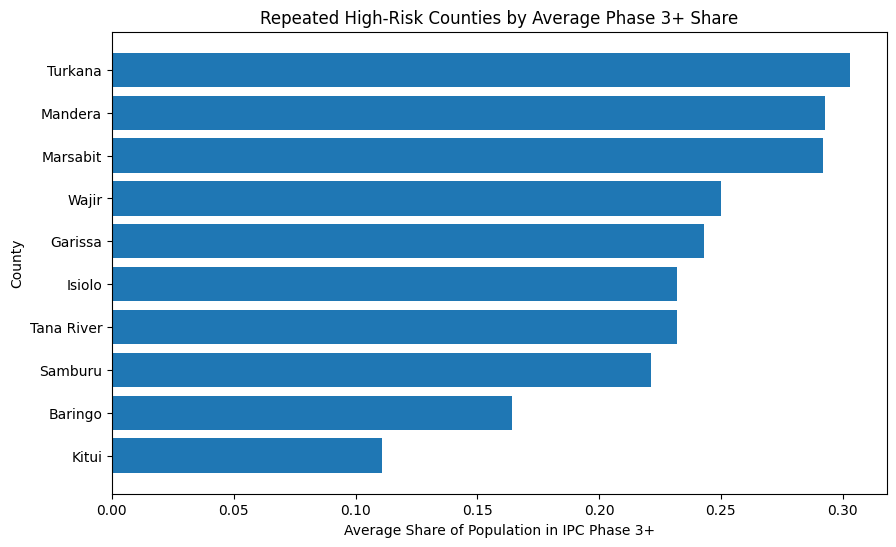

In [19]:
high_risk_counties_sorted = high_risk_counties.sort_values(
    "avg_phase_3_plus_percentage",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    high_risk_counties_sorted["county"],
    high_risk_counties_sorted["avg_phase_3_plus_percentage"]
)

plt.xlabel("Average Share of Population in IPC Phase 3+")
plt.ylabel("County")
plt.title("Repeated High-Risk Counties by Average Phase 3+ Share")
plt.gca().invert_yaxis()
plt.show()

### Interpretation

The repeated high-risk county analysis shows that Turkana, Mandera, Marsabit, Wajir, and Garissa consistently appear among the most food-insecure counties in the dataset. These counties combine frequent severe IPC classifications with high average shares of people in IPC Phase 3 or worse.

This result strengthens the case for treating northern and arid counties as priority areas in an early warning system. These counties should be monitored closely when climate, vegetation, and market-price predictors are added in the next stages of the project.

Overall, the EDA suggests that food insecurity risk is not evenly distributed across the target counties. A smaller group of counties appears repeatedly across severity, population-share, and population-burden analysis.

## EDA Summary

This exploratory analysis identified several repeated high-risk counties in the cleaned IPC dataset. Turkana, Mandera, Marsabit, Wajir, and Garissa appeared consistently across multiple risk views: Phase 4 frequency, average Phase 3+ population share, and absolute Phase 3+ population burden.

The analysis also showed that Jan 2023 was the highest-burden period in the dataset, with the total Phase 3+ population across the target counties reaching approximately 4.4 million people. Although the burden declined after Jan 2023, the trend increased again toward Feb 2026.

These findings provide the first evidence base for the next stage of the project: adding predictor datasets such as rainfall, vegetation health, and food prices to explain and eventually forecast food insecurity risk.